<a href="https://colab.research.google.com/github/Capaquira/projectsLivreLow-code/blob/Notebooks/TauxDesabonnementClients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import tensorflow as tf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_squared_log_error,
    r2_score,
    explained_variance_score
)

import warnings
# Ignorar todos los warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

Fuente Original de codigo oreil:

https://github.com/maabel0712/low-code-ai/tree/main/chapter7

https://github.com/maabel0712/low-code-ai/blob/main/chapter7/Customer_Churn_Model.ipynb


In [2]:
Source = pd.read_csv('https://storage.googleapis.com/low-code-ai-book/churn_dataset.csv',on_bad_lines = 'skip',engine='python')
Source.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
Source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
Source.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [5]:
Source

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
Source['TotalCharges'].describe()

,TotalCharges
count,7043
unique,6531
top,
freq,11


In [ ]:
mask = (Source['TotalCharges']==' ')
Source[mask].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [7]:
mask = (Source['tenure']==0)
Source[mask][['tenure','TotalCharges']]

,tenure,TotalCharges
488,0,
753,0,
936,0,
1082,0,
1340,0,
3331,0,
3826,0,
4380,0,
5218,0,
6670,0,


In [8]:
df_1 = Source.replace({'TotalCharges': {' ': 0.0}})
mask = (Source['tenure']==0)
df_1[mask][['tenure','TotalCharges']]

,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0
3331,0,0.0
3826,0,0.0
4380,0,0.0
5218,0,0.0
6670,0,0.0


In [9]:
df_2 = df_1.astype({'TotalCharges':'float64'})
df_2.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [20]:
df_2.describe().round(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000,7043.000,7043.000,7043.000
mean,0.162,32.371,64.762,2279.734
std,0.369,24.559,30.090,2266.794
min,0.000,0.000,18.250,0.000
25%,0.000,9.000,35.500,398.550
50%,0.000,29.000,70.350,1394.550
75%,0.000,55.000,89.850,3786.600
max,1.000,72.000,118.750,8684.800


Include Objets columns

In [21]:
df_2.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,3186-AJIEK,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


In [26]:
df_2.value_counts(['PhoneService','MultipleLines'])

PhoneService  MultipleLines   
Yes           No                  3390
              Yes                 2971
No            No phone service     682
Name: count, dtype: int64

In [25]:
df_2.value_counts(['InternetService','OnlineSecurity'])

InternetService  OnlineSecurity     
Fiber optic      No                     2257
No               No internet service    1526
DSL              No                     1241
                 Yes                    1180
Fiber optic      Yes                     839
Name: count, dtype: int64

In [27]:
df_2.value_counts(['InternetService', 'OnlineSecurity', 'OnlineBackup', 'StreamingTV', 'StreamingMovies'])

InternetService  OnlineSecurity       OnlineBackup         StreamingTV          StreamingMovies    
No               No internet service  No internet service  No internet service  No internet service    1526
Fiber optic      No                   No                   No                   No                      521
                                                           Yes                  Yes                     455
DSL              No                   No                   No                   No                      453
Fiber optic      No                   Yes                  Yes                  Yes                     428
                 Yes                  Yes                  Yes                  Yes                     270
DSL              Yes                  No                   No                   No                      246
                                      Yes                  No                   No                      233
Fiber optic      No                   No                   No                   Yes                     215
                                                           Yes                  No                      212
DSL              Yes                  Yes                  Yes                  Yes                     209
Fiber optic      No                   Yes                  No                   No                      192
DSL              No                   Yes                  No                   No                      181
Fiber optic      Yes                  No                   Yes                  Yes                     157
DSL              No                   No                   Yes                  Yes                     144
                 Yes                  No                   Yes                  Yes                     139
                 No                   Yes                  Yes                  Yes                     138
Fiber optic      No                   Yes                  Yes                  No                      119
                                                           No                   Yes                     115
                 Yes                  No                   No                   No                      107
DSL              Yes                  Yes                  No                   Yes                     100
                 No                   No                   No                   Yes                     100
                                                           Yes                  No                       95
                 Yes                  Yes                  Yes                  No                       95
                                      No                   No                   Yes                      88
Fiber optic      Yes                  Yes                  No                   No                       85
DSL              Yes                  No                   Yes                  No                       70
Fiber optic      Yes                  Yes                  Yes                  No                       67
DSL              No                   Yes                  Yes                  No                       67
Fiber optic      Yes                  Yes                  No                   Yes                      67
DSL              No                   Yes                  No                   Yes                      63
Fiber optic      Yes                  No                   No                   Yes                      44
                                                           Yes                  No                       42
Name: count, dtype: int64

<Axes: xlabel='Contract'>

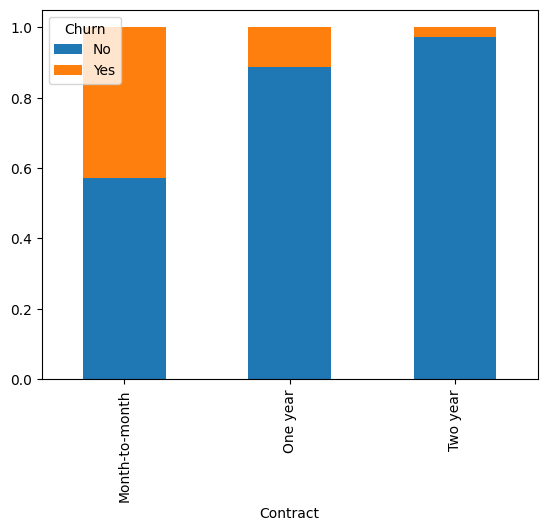

In [28]:
(df_2.groupby('Contract')['Churn'].value_counts(normalize=True)
  .unstack('Churn')
  .plot.bar(stacked=True))

In [30]:
def plot_cat_feature_dist(feature_name):
  (df_2.groupby(feature_name)['Churn'].value_counts(normalize=True)
    .unstack('Churn')
    .plot.bar(stacked=True))

In [34]:
df_2.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
type

In [ ]:
#features = df_2.columns
#for feature in features:
#  plot_cat_feature_dist(feature)

In [36]:
df_2['AvgMonthlyCharge'] = df_2['TotalCharges']/df_2['tenure']
df_2['DiffCharges'] = df_2['MonthlyCharges']-df_2['AvgMonthlyCharge']
df_2['DiffCharges'].describe()

,DiffCharges
count,7032.000000
mean,-0.001215
std,2.616165
min,-18.900000
25%,-1.160179
50%,0.000000
75%,1.147775
max,19.125000


In [38]:
df_2['AvgMonthlyCharge'] = df_2['TotalCharges'].div(df_2['tenure']).replace(np.inf,0)
df_2['DiffCharges'] = df_2['MonthlyCharges']-df_2['AvgMonthlyCharge']
df_2['DiffCharges'].describe()

,DiffCharges
count,7032.000000
mean,-0.001215
std,2.616165
min,-18.900000
25%,-1.160179
50%,0.000000
75%,1.147775
max,19.125000


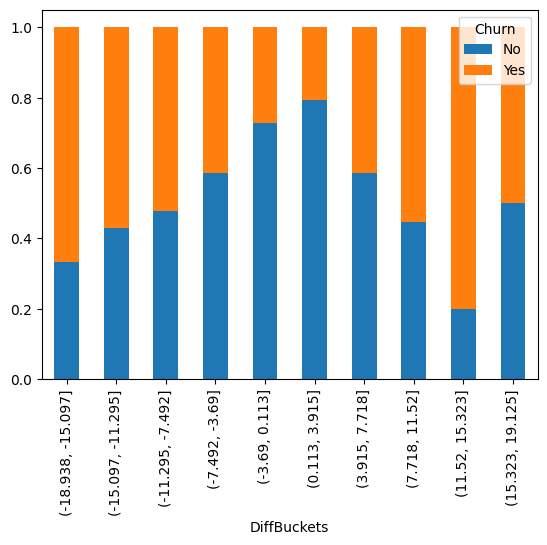

In [43]:
df_2['DiffBuckets'] = pd.cut(df_2['DiffCharges'], bins=10)
plot_cat_feature_dist('DiffBuckets')

# df_2['DiffBuckets'] = pd.cut(df_2['DiffCharges'].values, bins=5)
# plot_cat_feature_dist('DiffBuckets')

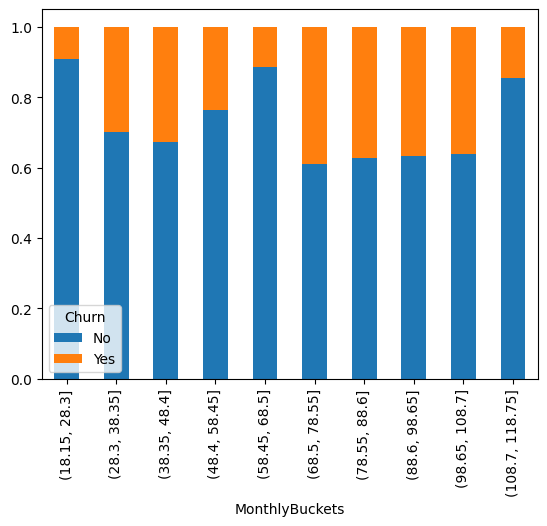

In [48]:
df_2['MonthlyBuckets'] = pd.cut(df_2['MonthlyCharges'], bins=10)
plot_cat_feature_dist('MonthlyBuckets')

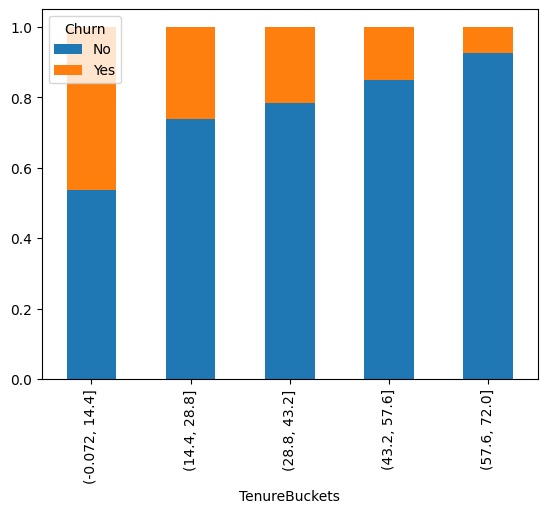

In [52]:
df_2['TenureBuckets'] = pd.cut(df_2['tenure'], bins=5)
plot_cat_feature_dist('TenureBuckets')

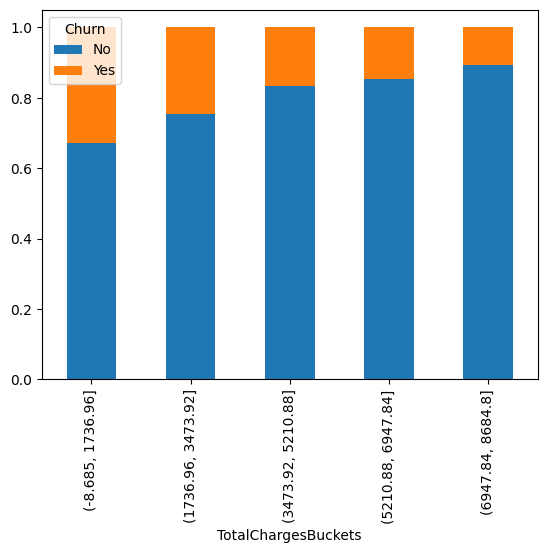

In [56]:
df_2['TotalChargesBuckets'] = pd.cut(df_2['TotalCharges'], bins=5)
plot_cat_feature_dist('TotalChargesBuckets')

In [11]:
Source.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
Source = Source.dropna()

In [14]:
Source.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [16]:
Source.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


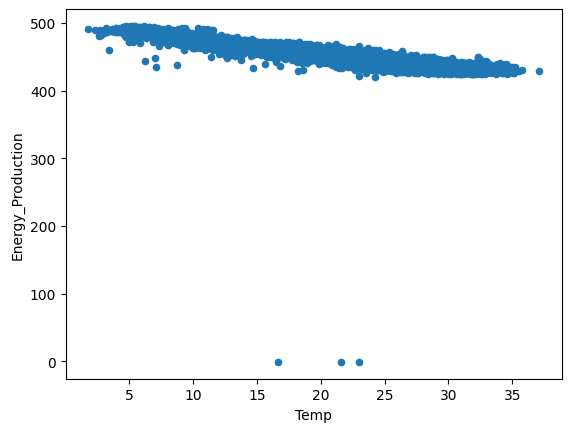

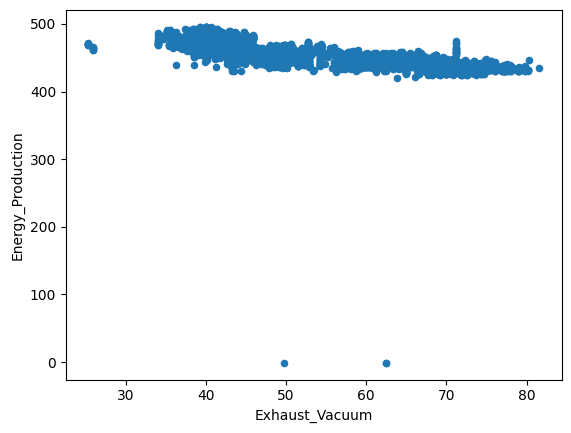

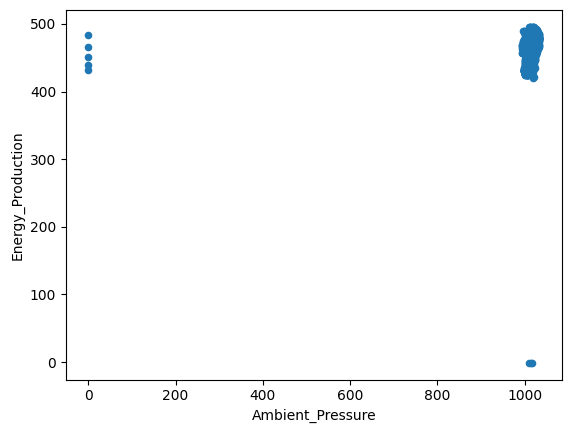

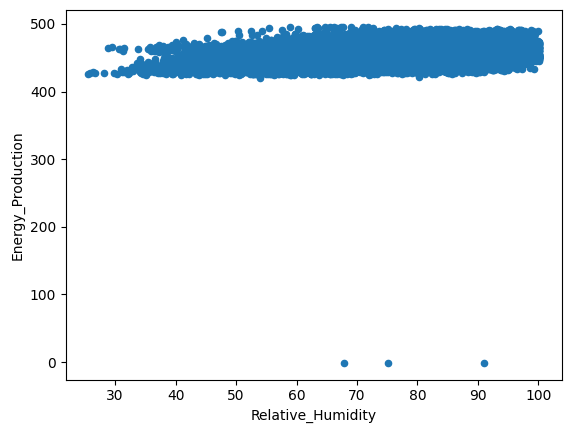

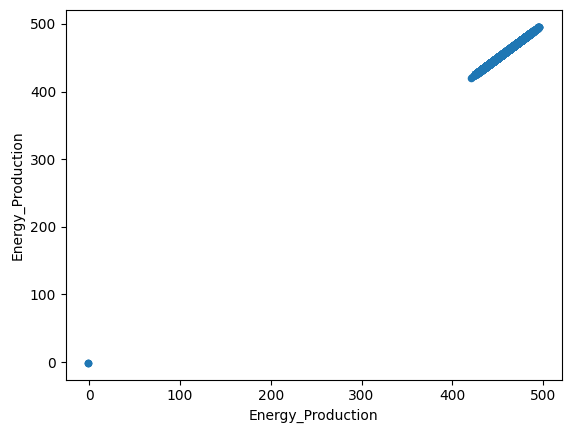

In [ ]:
for col in Source.columns:
    Source.plot.scatter(x=col, y='Energy_Production')
    plt.show()

**Normal Operating** **Conditions**

In [ ]:
Source.describe().round(2)

,Temp,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Production
count,9584.00,9584.00,9584.00,9584.00,9584.00
mean,19.65,54.31,1012.73,73.31,454.23
std,7.45,12.71,23.89,14.60,18.87
min,1.81,25.36,0.00,25.56,-1.00
25%,13.51,41.74,1009.10,63.33,439.74
50%,20.34,52.08,1012.94,74.97,451.50
75%,25.72,66.54,1017.26,84.83,468.43
max,37.11,81.56,1033.30,100.16,495.76


For this take into account the table with **the min and max ** but also the areas of importances **from the chart**

---



In [ ]:

limits = {
    'Temp': (1.81, 37.11),
    'Exhaust_Vacuum': (25.36, 81.56),
    'Ambient_Pressure': (800, 1033.30),
    'Relative_Humidity': (25.56, 100.16),
    'Energy_Production': (350, 550)
}

mask = pd.Series(True, index=Source.index)

for col, (min_val, max_val) in limits.items():
  mask &= Source[col].between(min_val, max_val)

Source_Filtrado = Source[mask]

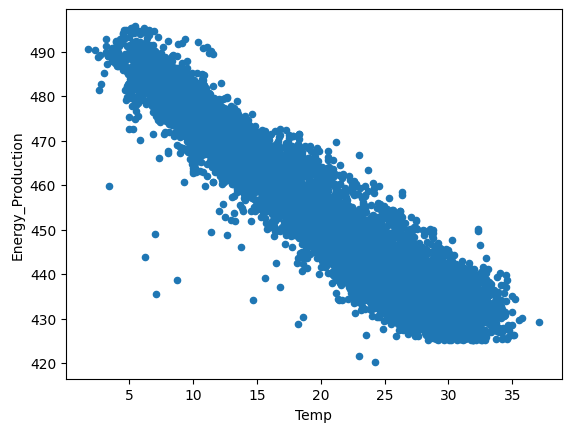

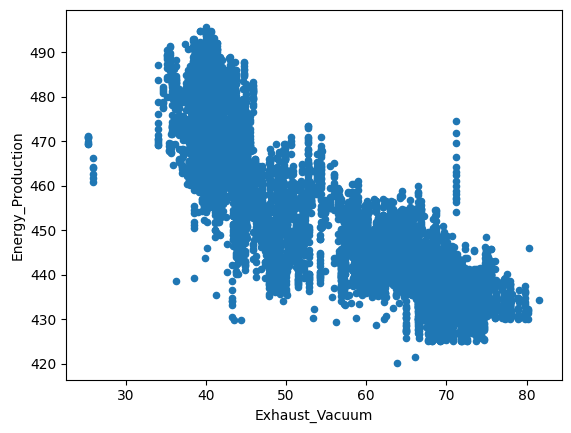

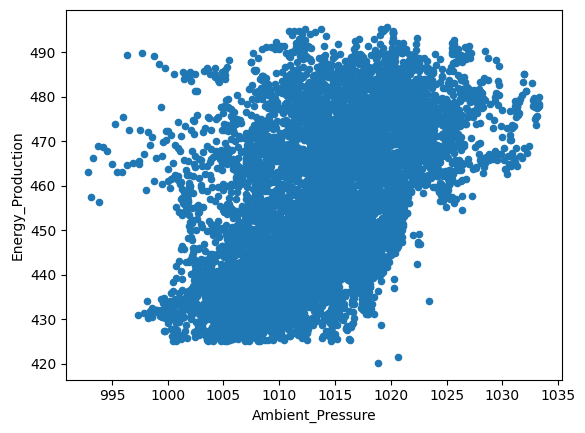

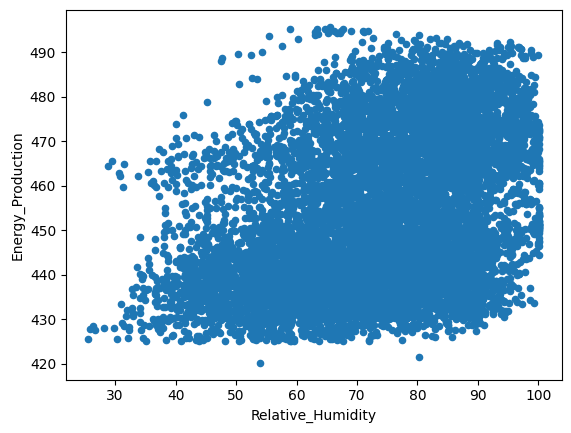

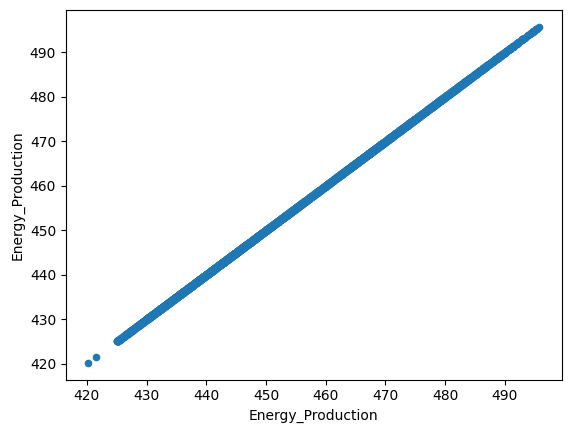

In [ ]:
for col in Source_Filtrado.columns:
    Source_Filtrado.plot.scatter(x=col, y='Energy_Production')
    plt.show()

**Correlation Factor**

In [ ]:
Source_Filtrado.corr().round(2)

,Temp,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Production
Temp,1.00,0.84,-0.51,-0.54,-0.95
Exhaust_Vacuum,0.84,1.00,-0.41,-0.31,-0.87
Ambient_Pressure,-0.51,-0.41,1.00,0.10,0.52
Relative_Humidity,-0.54,-0.31,0.10,1.00,0.39
Energy_Production,-0.95,-0.87,0.52,0.39,1.00


<Axes: >

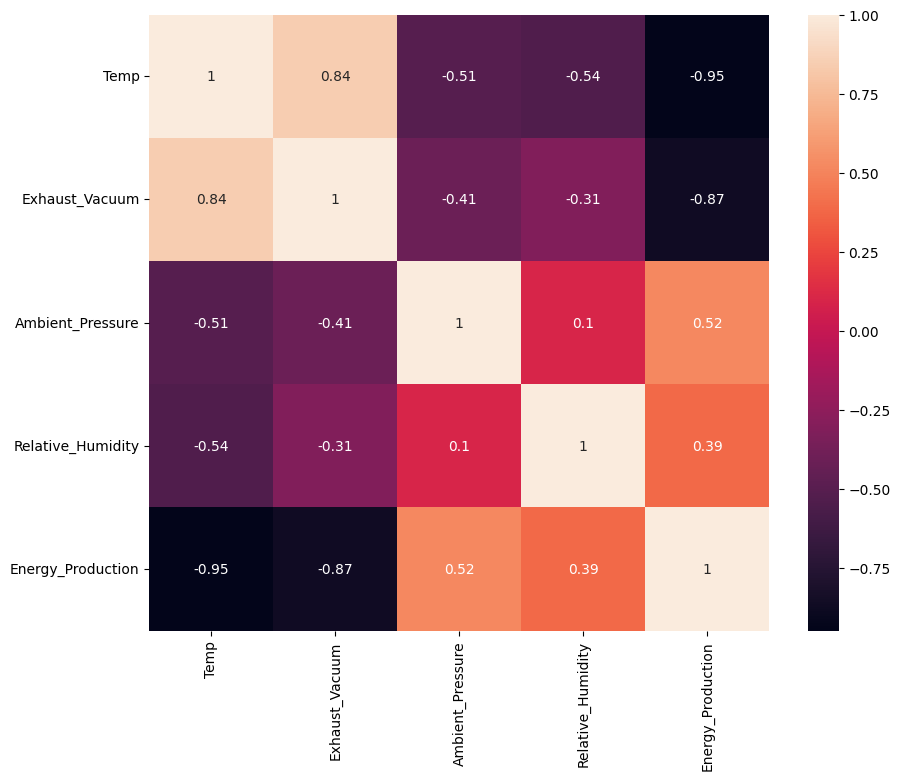

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(Source_Filtrado.corr(), annot=True)

<Axes: >

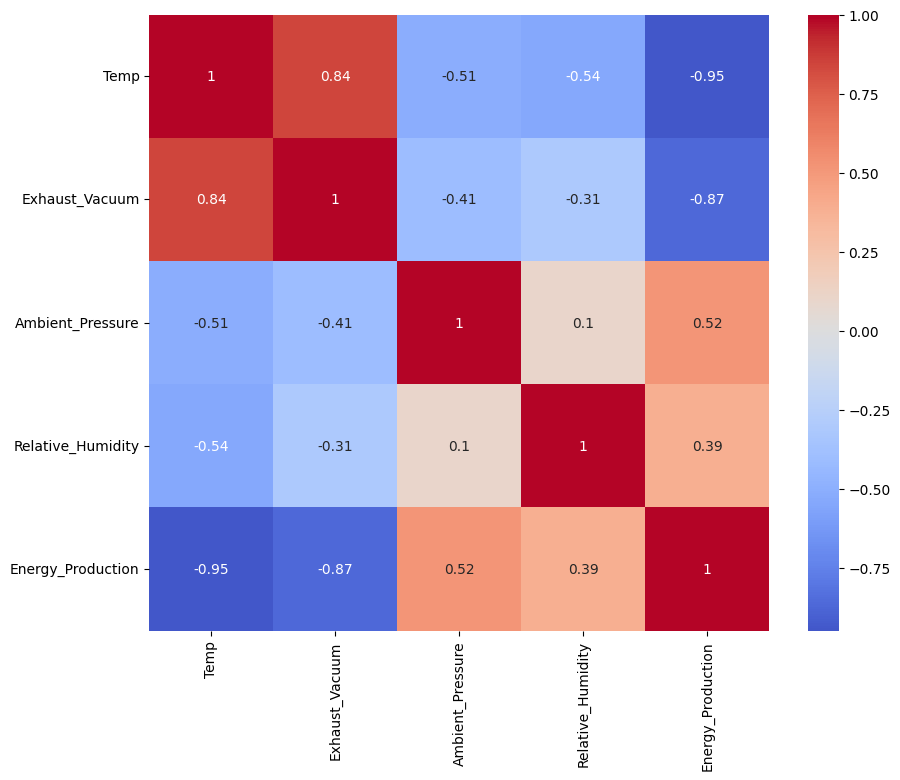

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(Source_Filtrado.corr(), annot=True,cmap="coolwarm",center=0)

**Linear model**

In [ ]:

# Separar variables
X = Source_Filtrado.drop(columns=['Energy_Production'])
y = Source_Filtrado['Energy_Production']

# Dividir datos (80% train, mezclados)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    shuffle=True,
    random_state=42
)

# Crear modelo
model = LinearRegression()

# Entrenar
model.fit(X_train, y_train)

# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Función para calcular métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    msle = mean_squared_log_error(y_true, np.maximum(0, y_pred))
    r2 = r2_score(y_true, y_pred)
    ev = explained_variance_score(y_true, y_pred)

    return [mae, mse, rmse, msle, r2, ev]

# Crear tabla
metricas = pd.DataFrame(
    [calcular_metricas(y_train, y_train_pred),
     calcular_metricas(y_test, y_test_pred)],
    columns=["MAE", "MSE", "RMSE", "MSLE", "R2", "Explained Variance"],
    index=["Train", "Test"]
)

In [ ]:
metricas.round(2)

,MAE,MSE,RMSE,MSLE,R2,Explained Variance
Train,3.62,20.59,4.54,0.0,0.93,0.93
Test,3.65,21.53,4.64,0.0,0.93,0.93


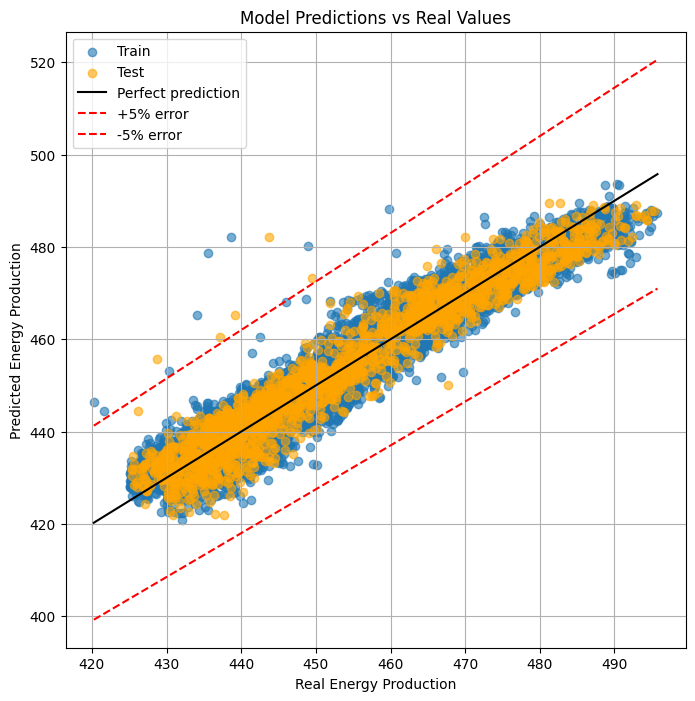

In [ ]:
plt.figure(figsize=(8,8))

# scatter
plt.scatter(y_train, y_train_pred, alpha=0.6, label="Train")
plt.scatter(y_test, y_test_pred, alpha=0.6, label="Test", color="orange")

# línea perfecta
min_val = min(y_test.min(), y_train.min())
max_val = max(y_test.max(), y_train.max())

x = np.linspace(min_val, max_val, 100)

plt.plot(x, x, color="black", label="Perfect prediction")

# banda ±5%
plt.plot(x, x*1.05, linestyle="--", color="red", label="+5% error")
plt.plot(x, x*0.95, linestyle="--", color="red", label="-5% error")

plt.xlabel("Real Energy Production")
plt.ylabel("Predicted Energy Production")
plt.title("Model Predictions vs Real Values")

plt.legend()
plt.grid(True)
plt.show()

**Predicciones Futuras**

In [ ]:
# Elegimos un ejemplo (primera fila del test)
fila = X_test.iloc[0]

# Predicción
pred = model.predict([fila])[0]

# Coeficientes del modelo
coef = pd.Series(model.coef_, index=X.columns)

# Contribución de cada feature
contribuciones = fila * coef

# Crear tabla
tabla = pd.DataFrame({
    'Valor Input': fila,
    'Coeficiente': coef,
    'Influencia': contribuciones
})

# Agregar fila de predicción total
tabla.loc['Predicción'] = ['', '', pred]

# Mostrar
print(tabla)

                  Valor Input Coeficiente  Influencia
Temp                    23.27   -1.978392  -46.037184
Exhaust_Vacuum          65.48   -0.233261  -15.273932
Ambient_Pressure      1019.05     0.06679   68.062587
Relative_Humidity       61.36   -0.157218   -9.646915
Predicción                                 446.859189


In [ ]:
tabla

,Valor Input,Coeficiente,Influencia
Temp,23.27,-1.978392,-46.037184
Exhaust_Vacuum,65.48,-0.233261,-15.273932
Ambient_Pressure,1019.05,0.06679,68.062587
Relative_Humidity,61.36,-0.157218,-9.646915
Predicción,,,446.859189


**Predicciones**

In [ ]:
# --- Nuevo dato de entrada ---
nuevo_dato = {
    'Temp': 27.45,
    'Exhaust_Vacuum': 65.12,
    'Ambient_Pressure': 1001.23,
    'Relative_Humidity': 84,
}

input_df = pd.DataFrame([nuevo_dato])

# --- Predicción ---
pred = model.predict(input_df)[0]

# --- Coeficientes del modelo ---
coef = pd.Series(model.coef_, index=X.columns)

# --- Influencia absoluta de cada feature ---
influencias = input_df.iloc[0] * coef

# --- Crear DataFrame inicial ---
ResultadosPregunta = pd.DataFrame({
    'Valor Input': input_df.iloc[0],
    'Coeficiente': coef,
    'Influencia Absoluta': influencias
})

# --- Fila del intercepto ---
intercepto = pd.DataFrame({
    'Valor Input': [None],
    'Coeficiente': [None],
    'Influencia Absoluta': [model.intercept_]
}, index=['Intercepto'])

# --- Concatenar al DataFrame ---
ResultadosPregunta = pd.concat([ResultadosPregunta, intercepto])

# --- Calcular porcentaje de influencia ---
ResultadosPregunta['Influencia (%)'] = (ResultadosPregunta['Influencia Absoluta'] / pred) * 100

# --- Fila de Predicción total ---
prediccion = pd.DataFrame({
    'Valor Input': [None],
    'Coeficiente': [None],
    'Influencia Absoluta': [pred],
    'Influencia (%)': [100.0]
}, index=['Predicción'])

ResultadosPregunta = pd.concat([ResultadosPregunta, prediccion])

# Mostrar tabla
ResultadosPregunta.round(2)

,Valor Input,Coeficiente,Influencia Absoluta,Influencia (%)
Temp,27.45,-1.98,-54.31,-12.52
Exhaust_Vacuum,65.12,-0.23,-15.19,-3.50
Ambient_Pressure,1001.23,0.07,66.87,15.41
Relative_Humidity,84.00,-0.16,-13.21,-3.04
Intercepto,NaN,NaN,449.75,103.65
Predicción,NaN,NaN,433.92,100.00


**Ai explicative**

Con LIME

In [ ]:
!pip install lime


LIME contribuciones (feature, valor):
Temp > 25.71 : -25.253617081353433
52.06 < Exhaust_Vacuum <= 66.51 : -1.8263258047437836
75.00 < Relative_Humidity <= 84.80 : -1.4868783006849722
Ambient_Pressure <= 1009.11 : -0.3164511339137592

Tabla SHAP para el nuevo dato:
             Feature  Valor Input  SHAP Value
0               Temp        27.45  -16.613745
1     Exhaust_Vacuum        65.12   -2.613153
2   Ambient_Pressure      1001.23   -0.869682
3  Relative_Humidity        84.00   -1.640180


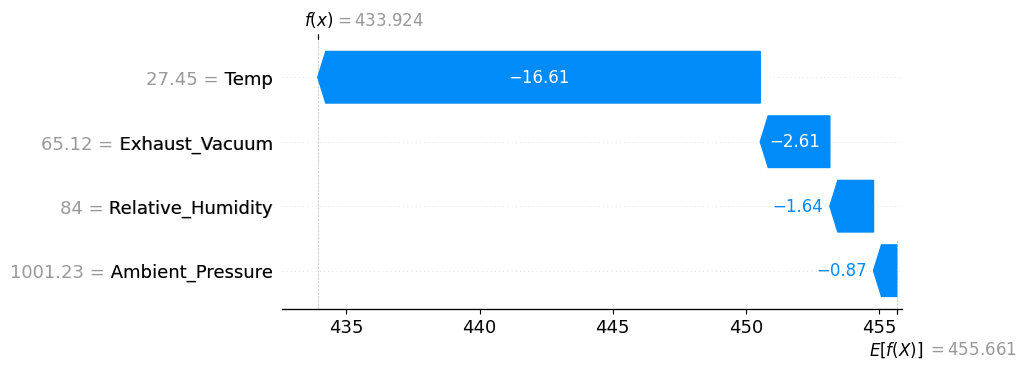

In [ ]:
# =======================
# --- LIME ---
# =======================
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    mode='regression'
)

exp = explainer_lime.explain_instance(
    data_row=input_df.iloc[0],
    predict_fn=model.predict
)

print("\nLIME contribuciones (feature, valor):")
for feature, valor in exp.as_list():
    print(feature, ":", valor)

# =======================
# --- SHAP ---
# =======================
explainer_shap = shap.Explainer(model, X_train)
shap_values = explainer_shap(input_df)

# Tabla SHAP
shap_tabla = pd.DataFrame({
    'Feature': X.columns,
    'Valor Input': input_df.iloc[0].values,
    'SHAP Value': shap_values.values[0]
})
print("\nTabla SHAP para el nuevo dato:")
print(shap_tabla)

# --- Gráfico SHAP Waterfall ---
shap.waterfall_plot(shap_values[0])

**Neural Network**

In [ ]:
# Modelo Simple

from sklearn.neural_network import MLPRegressor
import shap

# --- Modelo simple ---
model_simple = MLPRegressor(hidden_layer_sizes=(16,),  # 1 capa oculta de 16 neuronas
                            activation='relu',
                            solver='adam',
                            max_iter=1000,
                            random_state=42)

# Entrenar
model_simple.fit(X_train, y_train)

# Predicciones
y_train_pred = model_simple.predict(X_train)
y_test_pred = model_simple.predict(X_test)

# Función para calcular métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    msle = mean_squared_log_error(y_true, np.maximum(0, y_pred))
    r2 = r2_score(y_true, y_pred)
    ev = explained_variance_score(y_true, y_pred)

    return [mae, mse, rmse, msle, r2, ev]

# Crear tabla
metricas = pd.DataFrame(
    [calcular_metricas(y_train, y_train_pred),
     calcular_metricas(y_test, y_test_pred)],
    columns=["MAE", "MSE", "RMSE", "MSLE", "R2", "Explained Variance"],
    index=["Train", "Test"]
)

In [ ]:
metricas.round(2)

,MAE,MSE,RMSE,MSLE,R2,Explained Variance
Train,3.80,23.32,4.83,0.0,0.92,0.92
Test,3.87,24.77,4.98,0.0,0.92,0.92


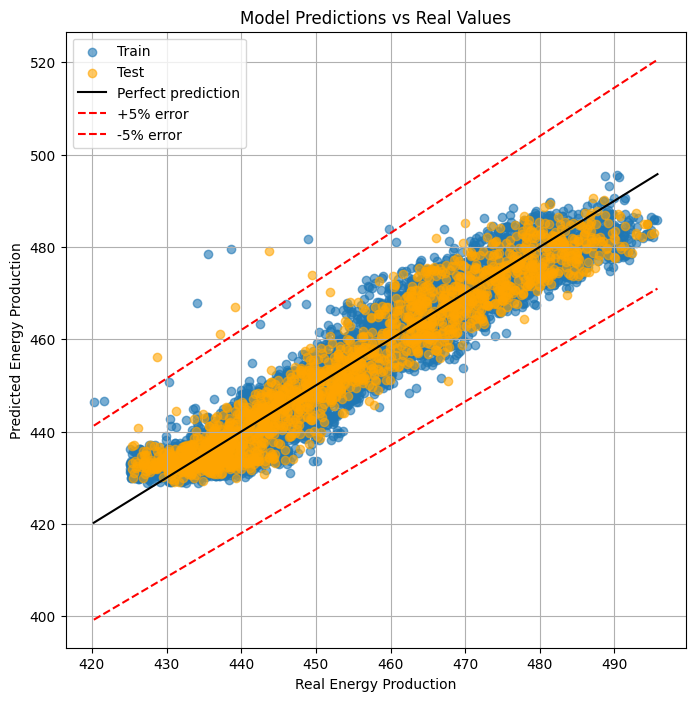

In [ ]:
plt.figure(figsize=(8,8))

# scatter
plt.scatter(y_train, y_train_pred, alpha=0.6, label="Train")
plt.scatter(y_test, y_test_pred, alpha=0.6, label="Test", color="orange")

# línea perfecta
min_val = min(y_test.min(), y_train.min())
max_val = max(y_test.max(), y_train.max())

x = np.linspace(min_val, max_val, 100)

plt.plot(x, x, color="black", label="Perfect prediction")

# banda ±5%
plt.plot(x, x*1.05, linestyle="--", color="red", label="+5% error")
plt.plot(x, x*0.95, linestyle="--", color="red", label="-5% error")

plt.xlabel("Real Energy Production")
plt.ylabel("Predicted Energy Production")
plt.title("Model Predictions vs Real Values")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# --- Nuevo dato de entrada ---
nuevo_dato = {
    'Temp': 27.45,
    'Exhaust_Vacuum': 65.12,
    'Ambient_Pressure': 1001.23,
    'Relative_Humidity': 84,
}

input_df = pd.DataFrame([nuevo_dato])

# --- Predicción ---
pred = model_simple.predict(input_df)[0]
print(pred.round(2))

429.35


In [ ]:
import shap

# Crear explainer SHAP (KernelExplainer para modelos de scikit-learn)
explainer = shap.KernelExplainer(model_simple.predict, X_train)

# Explicación para el nuevo dato
shap_values = explainer.shap_values(input_df)

# Valor base del modelo
base_value = explainer.expected_value
print(f"Valor base (similar a intercepto): {base_value:.2f}")

# Predicción
print(f"Predicción del nuevo dato: {pred2:.2f}")

  0%|          | 0/1 [00:00<?, ?it/s]

Valor base (similar a intercepto): 453.77
Predicción del nuevo dato: 429.35


In [ ]:
# Tabla con contribuciones de cada feature
shap_tabla = pd.DataFrame({
    'Feature': input_df.columns,
    'Valor Input': input_df.iloc[0].values,
    'Contribución SHAP': shap_values[0]
})

# Calcular % de contribución respecto a la predicción total
shap_tabla['Contribución (%)'] = (shap_tabla['Contribución SHAP'] / pred2) * 100

# Mostrar tabla
print(shap_tabla)

             Feature  Valor Input  Contribución SHAP  Contribución (%)
0               Temp        27.45         -13.938112         -3.246320
1     Exhaust_Vacuum        65.12          -3.838427         -0.894006
2   Ambient_Pressure      1001.23          -5.935825         -1.382511
3  Relative_Humidity        84.00          -0.707188         -0.164711


In [ ]:
# Modelo Complejo

model_deep = MLPRegressor(hidden_layer_sizes=(64, 32),  # 2 capas ocultas
                          activation='relu',
                          solver='adam',
                          max_iter=2000,
                          random_state=42)

# Entrenar
model_deep.fit(X_train, y_train)

# Predicciones
y_train_pred = model_deep.predict(X_train)
y_test_pred = model_deep.predict(X_test)

# Función para calcular métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    msle = mean_squared_log_error(y_true, np.maximum(0, y_pred))
    r2 = r2_score(y_true, y_pred)
    ev = explained_variance_score(y_true, y_pred)

    return [mae, mse, rmse, msle, r2, ev]

# Crear tabla
metricas = pd.DataFrame(
    [calcular_metricas(y_train, y_train_pred),
     calcular_metricas(y_test, y_test_pred)],
    columns=["MAE", "MSE", "RMSE", "MSLE", "R2", "Explained Variance"],
    index=["Train", "Test"]
)

In [ ]:
metricas.round(2)

,MAE,MSE,RMSE,MSLE,R2,Explained Variance
Train,4.17,26.85,5.18,0.0,0.91,0.92
Test,4.27,28.72,5.36,0.0,0.90,0.91


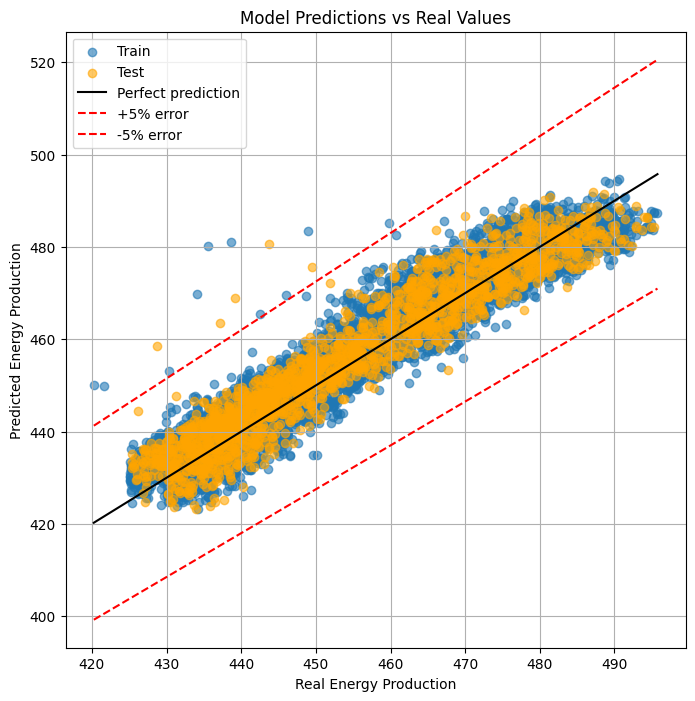

In [ ]:
plt.figure(figsize=(8,8))

# scatter
plt.scatter(y_train, y_train_pred, alpha=0.6, label="Train")
plt.scatter(y_test, y_test_pred, alpha=0.6, label="Test", color="orange")

# línea perfecta
min_val = min(y_test.min(), y_train.min())
max_val = max(y_test.max(), y_train.max())

x = np.linspace(min_val, max_val, 100)

plt.plot(x, x, color="black", label="Perfect prediction")

# banda ±5%
plt.plot(x, x*1.05, linestyle="--", color="red", label="+5% error")
plt.plot(x, x*0.95, linestyle="--", color="red", label="-5% error")

plt.xlabel("Real Energy Production")
plt.ylabel("Predicted Energy Production")
plt.title("Model Predictions vs Real Values")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Optimal Model

from sklearn.model_selection import GridSearchCV

# Definir modelo base
model_base = MLPRegressor(activation='relu', solver='adam', max_iter=2000, random_state=42)

# Grid de hiperparámetros
param_grid = {
    'hidden_layer_sizes': [(16,), (32,), (64,), (64,32), (128,64,32)],
    'learning_rate_init': [0.01, 0.001],
    'batch_size': [16, 32]
}

# GridSearch
grid = GridSearchCV(model_base, param_grid, cv=3, scoring='r2', verbose=1)
grid.fit(X_train, y_train)

# Mejor modelo
best_model = grid.best_estimator_
print("Mejores parámetros encontrados:", grid.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Mejores parámetros encontrados: {'batch_size': 32, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.01}


In [ ]:
# Predicciones
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Función para calcular métricas
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    msle = mean_squared_log_error(y_true, np.maximum(0, y_pred))
    r2 = r2_score(y_true, y_pred)
    ev = explained_variance_score(y_true, y_pred)

    return [mae, mse, rmse, msle, r2, ev]

# Crear tabla
metricas = pd.DataFrame(
    [calcular_metricas(y_train, y_train_pred),
     calcular_metricas(y_test, y_test_pred)],
    columns=["MAE", "MSE", "RMSE", "MSLE", "R2", "Explained Variance"],
    index=["Train", "Test"]
)

In [ ]:
metricas.round(2)

,MAE,MSE,RMSE,MSLE,R2,Explained Variance
Train,4.41,30.46,5.52,0.0,0.89,0.92
Test,4.53,32.09,5.67,0.0,0.89,0.92


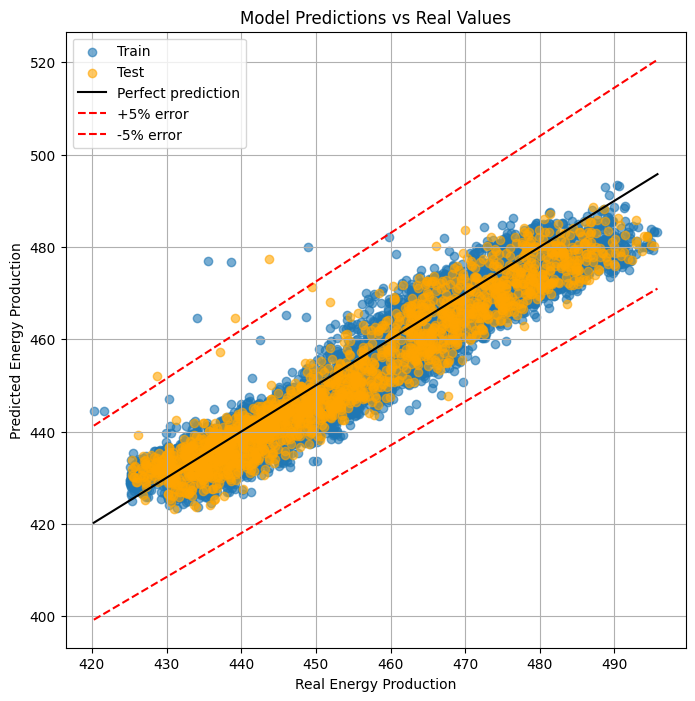

In [ ]:
plt.figure(figsize=(8,8))

# scatter
plt.scatter(y_train, y_train_pred, alpha=0.6, label="Train")
plt.scatter(y_test, y_test_pred, alpha=0.6, label="Test", color="orange")

# línea perfecta
min_val = min(y_test.min(), y_train.min())
max_val = max(y_test.max(), y_train.max())

x = np.linspace(min_val, max_val, 100)

plt.plot(x, x, color="black", label="Perfect prediction")

# banda ±5%
plt.plot(x, x*1.05, linestyle="--", color="red", label="+5% error")
plt.plot(x, x*0.95, linestyle="--", color="red", label="-5% error")

plt.xlabel("Real Energy Production")
plt.ylabel("Predicted Energy Production")
plt.title("Model Predictions vs Real Values")

plt.legend()
plt.grid(True)
plt.show()